In [80]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
heart_data=pd.read_csv('/content/heart_disease_data.csv')

In [82]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [83]:
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [84]:
heart_data.shape

(303, 14)

In [85]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [86]:
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [87]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [88]:
heart_data['target'].value_counts()

,count
target,
1,165
0,138


In [89]:
X=heart_data.drop(columns='target',axis=1)
Y=heart_data['target']

In [90]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [91]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


In [92]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [93]:
print(X.shape,X_train.shape,X_test.shape)

(303, 13) (242, 13) (61, 13)


In [94]:
lmodel = LogisticRegression()

In [95]:
lmodel.fit(X_train,Y_train)
X_train_prediction=lmodel.predict(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [96]:
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print(f'Accuracy on training data: {training_data_accuracy}')
model_recall=recall_score(X_train_prediction,Y_train)
print(f'Recall on training data: {model_recall}')
model_precision=precision_score(X_train_prediction,Y_train)
print(f'Precision on training data: {model_precision}')
model_f1=f1_score(X_train_prediction,Y_train)
print(f'F1 score on training data: {model_f1}')

Accuracy on training data: 0.8512396694214877
Recall on training data: 0.8287671232876712
Precision on training data: 0.9166666666666666
F1 score on training data: 0.8705035971223022


In [97]:
X_test_prediction=lmodel.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)
print(f'Accuracy on test data: {test_data_accuracy}')
model_recall=recall_score(X_test_prediction,Y_test)
print(f'Recall on test data: {model_recall}')
model_precision=precision_score(X_test_prediction,Y_test)
print(f'Precision on test data: {model_precision}')
model_f1=f1_score(X_test_prediction,Y_test)
print(f'F1 score on test data: {model_f1}')

Accuracy on test data: 0.819672131147541
Recall on test data: 0.84375
Precision on test data: 0.8181818181818182
F1 score on test data: 0.8307692307692308


Text(95.72222222222221, 0.5, 'Truth')

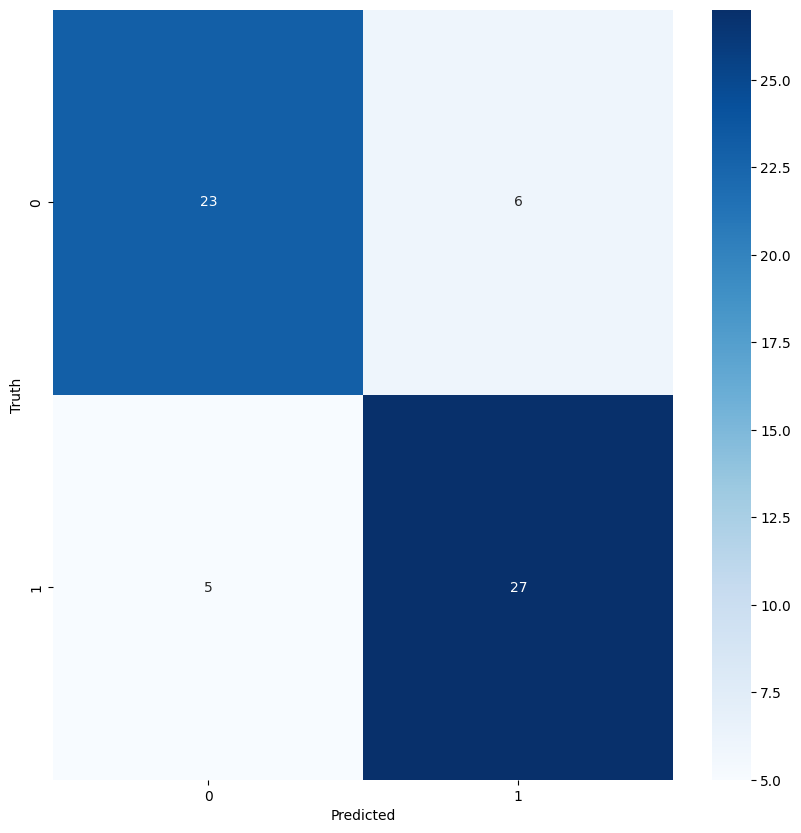

In [98]:
conf=confusion_matrix(X_test_prediction,Y_test)
plt.figure(figsize=(10,10))
sns.heatmap(conf,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

### K-Nearest Neighbors (KNN) Classifier

In [99]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, Y_train)


KNeighborsClassifier()

In [100]:
X_train_prediction_knn = knn_model.predict(X_train)
training_data_accuracy_knn = accuracy_score(X_train_prediction_knn, Y_train)
print(f'KNN Accuracy on training data: {training_data_accuracy_knn}')
model_recall_knn = recall_score(X_train_prediction_knn, Y_train)
print(f'KNN Recall on training data: {model_recall_knn}')
model_precision_knn = precision_score(X_train_prediction_knn, Y_train)
print(f'KNN Precision on training data: {model_precision_knn}')
model_f1_knn = f1_score(X_train_prediction_knn, Y_train)
print(f'KNN F1 score on training data: {model_f1_knn}')

KNN Accuracy on training data: 0.78099173553719
KNN Recall on training data: 0.7883211678832117
KNN Precision on training data: 0.8181818181818182
KNN F1 score on training data: 0.8029739776951673


In [101]:
X_test_prediction_knn = knn_model.predict(X_test)
test_data_accuracy_knn = accuracy_score(X_test_prediction_knn, Y_test)
print(f'KNN Accuracy on test data: {test_data_accuracy_knn}')
model_recall_knn = recall_score(X_test_prediction_knn, Y_test)
print(f'KNN Recall on test data: {model_recall_knn}')
model_precision_knn = precision_score(X_test_prediction_knn, Y_test)
print(f'KNN Precision on test data: {model_precision_knn}')
model_f1_knn = f1_score(X_test_prediction_knn, Y_test)
print(f'KNN F1 score on test data: {model_f1_knn}')

KNN Accuracy on test data: 0.6229508196721312
KNN Recall on test data: 0.6470588235294118
KNN Precision on test data: 0.6666666666666666
KNN F1 score on test data: 0.6567164179104478


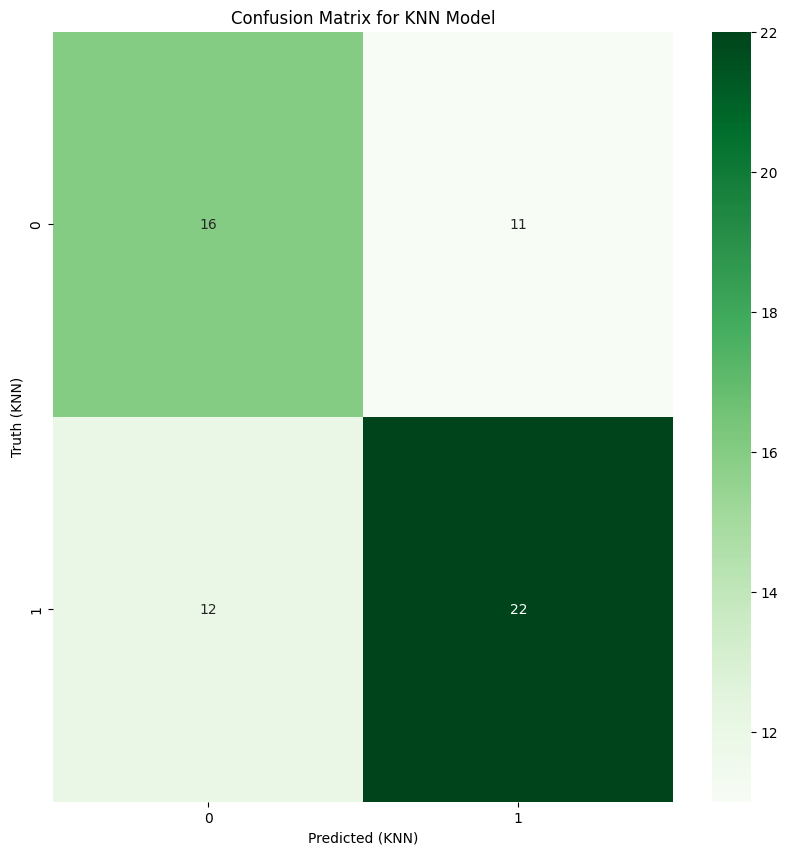

In [102]:
conf_knn = confusion_matrix(X_test_prediction_knn, Y_test)
plt.figure(figsize=(10,10))
sns.heatmap(conf_knn, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted (KNN)')
plt.ylabel('Truth (KNN)')
plt.title('Confusion Matrix for KNN Model')
plt.show()